# Exercise 1

In [2]:
import pandas as pd

# Load the dataset from the contents folder in Colab
df = pd.read_csv('/content/SpamDetectionData.txt')

# Display the first 3 rows to understand the structure
print(df.head(3))

# Display the column names in the dataset
print("\nColumns in the dataset:", df.columns.tolist())

  Label                                            Message
0  Spam  <p>But could then once pomp to nor that glee g...
1  Spam  <p>His honeyed and land vile are so and native...
2  Spam  <p>Tear womans his was by had tis her eremites...

Columns in the dataset: ['Label', 'Message']


In [3]:
# Extract X (messages) and y (labels)
X = df['Message']
y = df['Label']

In [4]:
# Remove <p> and </p> tags from each message
X = X.str.replace('<p>', '', regex=False)
X = X.str.replace('</p>', '', regex=False)

In [7]:
# Display number of characters in the first and second message
print("Number of characters in the first message:", len(X.iloc[0]))
print("Number of characters in the second message:", len(X.iloc[1]))

Number of characters in the first message: 417
Number of characters in the second message: 859


In [8]:
# Import the function for splitting the dataset
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (90% train, 10% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Display the sizes of each set
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 1890
Test set size: 210


In [10]:
!pip install keras

In [12]:
# Import the Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

In [13]:
# Initialize the Tokenizer and fit it on the training data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

In [14]:
# Convert training and test messages to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [15]:
# Get the three most common words
word_counts = tokenizer.word_counts  # dictionary: word -> count
sorted_words = sorted(word_counts.items(), key=lambda item: item[1], reverse=True)
most_common_words = sorted_words[:3]

In [16]:
print("Three most common words in the training set:")
for word, count in most_common_words:
    print(f"{word}: {count} occurrences")

# Show the first training sentence and its corresponding sequence
print("\nFirst training message:")
print(X_train.iloc[0])
print("\nTokenized as integer sequence:")
print(X_train_seq[0])

Three most common words in the training set:
the: 23042 occurrences
and: 19393 occurrences
of: 11189 occurrences

First training message:
Fluttered dreary a the of yore stock and curious we many wore the the radiant bust tapping sir this. The ghost distinctly and quoth angels the chamber broken or ghost sitting grave its this. The dreaming and art when adore and moment then and lord she lent i quoth adore tell mystery mefilled. Still nevermore the fiery above rare hath ever my and.Lining each no peering mefilled token and one ghastly the. The seraphim the on the flutter there in to sad desolate gently many then my little. Name napping above said pondered from while.Stood unseen came plume my horror there nevermore caught flitting again a still get or and thy muttered. Had to divining hath whether implore and human balm all it by guessing here have curtain such here. Explore my implore beating sitting. But nevermore tempter before sent my sought our for have. Till on grave censer this w

In [17]:
from keras.preprocessing.sequence import pad_sequences
import numpy as np

In [18]:
# Function to pad/truncate sequences to the same length
def vectorize_sequences(sequences, dimension):
    # Pad sequences with zeros to the same length (dimension)
    return pad_sequences(sequences, maxlen=dimension)

In [19]:
# Function to convert 'spam'/'ham' labels to 1/0
def vectorize_labels(labels):
    return np.array([1 if label.lower() == 'spam' else 0 for label in labels])

In [27]:
# Apply vectorization
max_length = 4000  # Fixed length of input vectors
X_train_vec = vectorize_sequences(X_train_seq, max_length)
X_test_vec = vectorize_sequences(X_test_seq, max_length)

In [28]:
y_train_vec = vectorize_labels(y_train)
y_test_vec = vectorize_labels(y_test)

In [29]:
# Let's check shapes just to confirm
print("X_train_vec shape:", X_train_vec.shape)
print("y_train_vec shape:", y_train_vec.shape)

X_train_vec shape: (1890, 4000)
y_train_vec shape: (1890,)


In [30]:
from keras.models import Sequential
from keras.layers import Dense

In [31]:
# Define the Sequential model
model = Sequential()

# First hidden layer with 8 neurons and ReLU activation
model.add(Dense(8, activation='relu', input_shape=(4000,)))

# Second hidden layer with 8 neurons and ReLU activation
model.add(Dense(8, activation='relu'))

# Output layer with 1 neuron and sigmoid activation (for binary classification)
model.add(Dense(1, activation='sigmoid'))

# Show a summary of the model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 8)                   │          32,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,089 (125.35 KB)

 Trainable params: 32,089 (125.35 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Compile the model
model.compile(
    optimizer='rmsprop',                # RMSprop optimizer
    loss='binary_crossentropy',         # Binary crossentropy loss function for binary classification
    metrics=['accuracy']                # Track accuracy during training and evaluation
)

In [34]:
# Train the model
history = model.fit(
    X_train_vec,               # Vectorized training data
    y_train_vec,               # Vectorized labels
    epochs=5,                  # Number of epochs
    batch_size=128,           # Batch size
    validation_split=0.3      # 30% of training data for validation
)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5198 - loss: 10.6354 - val_accuracy: 0.5450 - val_loss: 0.9471
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5311 - loss: 0.8362 - val_accuracy: 0.5432 - val_loss: 0.7938
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5351 - loss: 0.7373 - val_accuracy: 0.5432 - val_loss: 0.7569
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5161 - loss: 0.6951 - val_accuracy: 0.5362 - val_loss: 0.7654
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5067 - loss: 0.6983 - val_accuracy: 0.5414 - val_loss: 0.7375


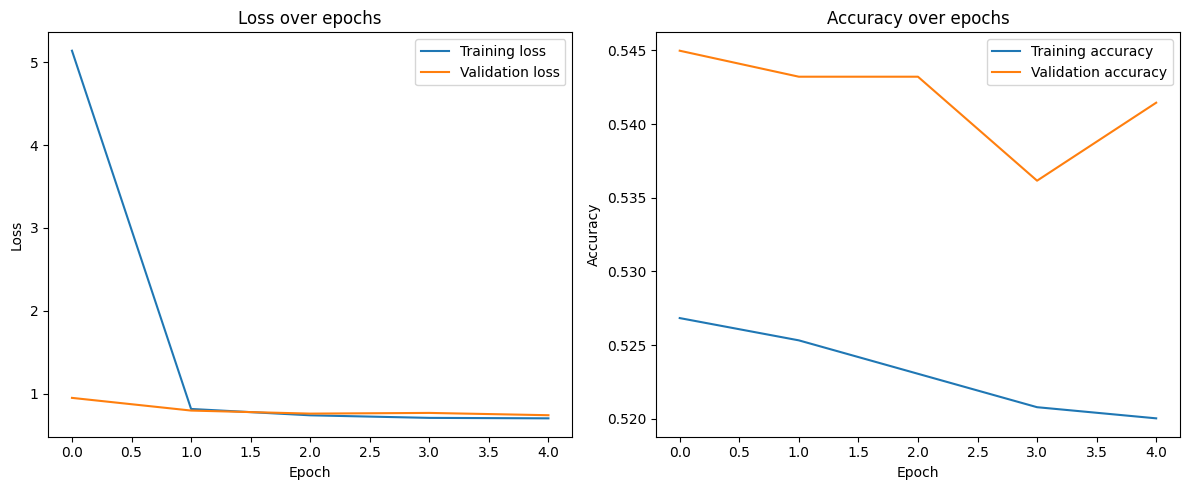

In [35]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_vec, y_test_vec)

# Display the results
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5427 - loss: 0.6898 
Test Loss: 0.6884286999702454
Test Accuracy: 0.523809552192688


In [38]:
# Step 1: Define a custom message
custom_message = "Congratulations! You have won a free vacation trip to the Bahamas. Contact us at 1-800-123-4567."

In [39]:
# Step 2: Tokenize the custom message
custom_message_seq = tokenizer.texts_to_sequences([custom_message])

# Step 3: Pad the sequence to ensure it's of the correct length (4000 in this case)
custom_message_padded = pad_sequences(custom_message_seq, maxlen=4000)

# Step 4: Make a prediction using the trained model
prediction = model.predict(custom_message_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [40]:
# Step 5: Display the result
if prediction >= 0.5:
    print("The message is classified as 'Spam'")
else:
    print("The message is classified as 'Ham'")

The message is classified as 'Spam'


# Exercise 2

In [41]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/stackoverflow.csv')

# Display the last 3 rows
data.tail(3)

,post,tags
1987,directory folder name to put user defined pack...,java
1988,send message to server java i m creating chat...,java
1989,how to add pattern of * is url-pattern in we...,java


In [44]:
# Extracting X (questions) and y (labels)
X = data['post']
y = data['tags']

In [45]:
# Check how many unique labels there are and list them
unique_labels = y.unique()

# Number of unique labels
num_unique_labels = len(unique_labels)

# List of unique programming languages
unique_labels_list = unique_labels

num_unique_labels, unique_labels_list

(4, array(['java', 'javascript', 'c#', 'python'], dtype=object))

In [46]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

In [47]:
# Step 1: Map textual labels to integers using LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # y is the labels from the dataset

In [48]:
# Step 2: Perform one-hot encoding using to_categorical
y_one_hot = to_categorical(y_encoded)

In [49]:
# Display the one-hot encoded labels
y_one_hot[:5]  # Displaying the first 5 for verification

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [65]:
from sklearn.model_selection import train_test_split

# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.1, random_state=42)

# Display the shapes of the splits to verify
print("Training set size (X_train, y_train):", X_train.shape, y_train.shape)
print("Test set size (X_test, y_test):", X_test.shape, y_test.shape)

Training set size (X_train, y_train): (1791,) (1791, 4)
Test set size (X_test, y_test): (199,) (199, 4)



--- Analyzing Post Lengths for 'maxlen' ---


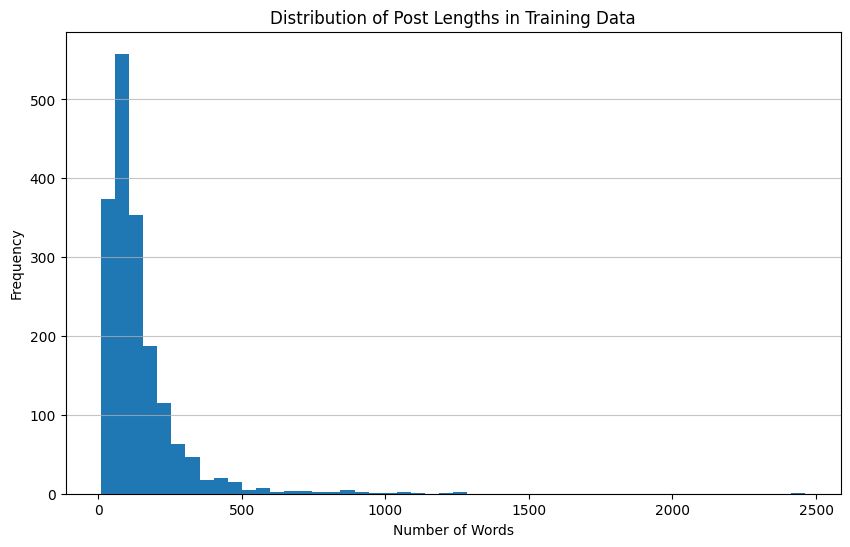


Post Length Statistics:
count    1791.000000
mean      142.750419
std       143.905124
min        10.000000
50%       105.000000
75%       169.000000
90%       267.000000
95%       374.000000
99%       792.300000
max      2463.000000
Name: post, dtype: float64

Suggested 'maxlen' considerations:
- Median length: 105
- 90th percentile length: 267
- 95th percentile length: 374
- Max observed length: 2463
-> Choose a 'maxlen' that covers a high percentile (e.g., 90% or 95%) without being overly large if there are extreme outliers.

--- Analyzing Vocabulary for 'num_words' ---
Total unique words found in training data: 18113

Vocabulary Coverage (Percentage of total word occurrences covered):
- Top 100   words cover: 47.67%
- Top 500   words cover: 70.42%
- Top 1000  words cover: 78.55%
- Top 5000  words cover: 92.32%
- Top 10000 words cover: 96.91%
- Top 18113 words cover: 100.00%

Suggested 'num_words' considerations:
-> Select a 'num_words' based on the coverage percentage you find acc

In [85]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import re # For slightly better tokenization

# --- Analysis for Choosing maxlen ---
print("\n--- Analyzing Post Lengths for 'maxlen' ---")

# Calculate the number of words in each post (simple space split)
post_lengths = X_train.apply(lambda x: len(x.split()))

# Plot the distribution of post lengths
plt.figure(figsize=(10, 6))
plt.hist(post_lengths, bins=50)
plt.title('Distribution of Post Lengths in Training Data')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Calculate descriptive statistics, especially percentiles
print("\nPost Length Statistics:")
print(post_lengths.describe(percentiles=[.5, .75, .90, .95, .99]))

# Suggestion based on percentiles
# Often, choosing the 90th, 95th, or 99th percentile is a good balance
# between capturing most data and avoiding excessive padding due to outliers.
median_len = int(post_lengths.median())
p90_len = int(post_lengths.quantile(0.90))
p95_len = int(post_lengths.quantile(0.95))
max_len_observed = post_lengths.max()

print(f"\nSuggested 'maxlen' considerations:")
print(f"- Median length: {median_len}")
print(f"- 90th percentile length: {p90_len}")
print(f"- 95th percentile length: {p95_len}")
print(f"- Max observed length: {max_len_observed}")
print("-> Choose a 'maxlen' that covers a high percentile (e.g., 90% or 95%) \
without being overly large if there are extreme outliers.")


# --- Analysis for Choosing num_words ---
print("\n--- Analyzing Vocabulary for 'num_words' ---")

# Combine all training posts into one large text
full_text = ' '.join(X_train)

# Simple tokenization: lowercase and split by non-alphanumeric characters
# This is a basic approach; more sophisticated tokenizers exist
words = re.findall(r'\b\w+\b', full_text.lower())

# Count word frequencies
word_counts = Counter(words)
total_unique_words = len(word_counts)

print(f"Total unique words found in training data: {total_unique_words}")

# Calculate cumulative frequency coverage
sorted_words = word_counts.most_common()
total_word_occurrences = sum(word_counts.values())
cumulative_coverage = 0
coverage_points = [100, 500, 1000, 5000, 10000, 20000, 50000]
coverage_results = {}

word_rank = 0
for word, count in sorted_words:
    word_rank += 1
    cumulative_coverage += count
    # Check coverage at predefined points
    while coverage_points and word_rank >= coverage_points[0]:
        point = coverage_points.pop(0)
        if word_rank >= point: # Ensure we don't double-count if ranks are skipped
             coverage_results[point] = (cumulative_coverage / total_word_occurrences) * 100

# Ensure all points are covered even if vocab is smaller
for point in coverage_points:
     if point not in coverage_results:
          coverage_results[point] = (cumulative_coverage / total_word_occurrences) * 100


print("\nVocabulary Coverage (Percentage of total word occurrences covered):")
# Sort results by vocab size for printing
for vocab_size in sorted(coverage_results.keys()):
     if vocab_size <= total_unique_words:
         print(f"- Top {vocab_size:<5} words cover: {coverage_results[vocab_size]:.2f}%")
     else:
         # Avoid printing points larger than the actual vocabulary
         break
# Print coverage for the full vocabulary
print(f"- Top {total_unique_words:<5} words cover: 100.00%")


print("\nSuggested 'num_words' considerations:")
print("-> Select a 'num_words' based on the coverage percentage you find acceptable.")
print("-> Higher coverage captures more information but increases model complexity (embedding size).")
print("-> Common starting points are often 5000, 10000, or 20000, depending on the task and dataset size.")
print(f"-> Your current setting is 500 words. Based on the coverage analysis above, \
see how much of the text that actually represents.")


In [86]:
# Step 1: Initialize Tokenizer with 1000 most common words
tokenizer = Tokenizer(num_words=1000)  # Limit the tokenizer to the 1000 most frequent words
tokenizer.fit_on_texts(X_train)  # Fit the tokenizer on the text data (questions)

In [87]:
# Step 2: Convert the questions (X) into sequences of integers
X_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [88]:
# Step 3: Pad the sequences to ensure they have the same length
X_padded = pad_sequences(X_sequences, maxlen=374)  # Adjust maxlen to desired length
X_test_padded = pad_sequences(X_test_sequences, maxlen=374)

In [89]:
print("Example sequence before padding:", X_sequences[0])
print("Example sequence after padding:", X_padded[0])

Example sequence before padding: [2, 118, 5, 4, 180, 759, 5, 733, 5, 337, 17, 1, 337, 484, 57, 122, 1, 337, 10, 9, 893, 32, 893, 18, 120, 562, 551, 65, 443, 205, 80, 120, 164, 2, 54, 18, 74, 325, 74, 337, 18, 893, 2, 185, 259, 599, 99, 99, 99, 74, 325, 74, 99, 99, 99, 99, 74, 325, 562, 74, 99, 99, 99, 99, 99, 99, 99, 99, 74, 325, 74, 99, 99, 99, 99, 99, 99, 74, 74, 99, 99, 74, 325, 74, 99, 99, 74, 74, 99, 599]
Example sequence after padding: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   

In [90]:
# Define the number of classes (unique programming languages)
num_classes = y_train.shape[1]  # This assumes y_train is already one-hot encoded

# Create a sequential model
model = Sequential()

# First Dense layer with 32 neurons and ReLU activation
model.add(Dense(32, input_dim=X_padded.shape[1], activation='relu'))

# Second Dense layer with 8 neurons and ReLU activation
model.add(Dense(8, activation='relu'))

# Output layer with the number of neurons equal to the number of classes, Softmax activation
model.add(Dense(num_classes, activation='softmax'))

# Display the model summary to review its structure
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 32)                  │          12,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,300 (48.05 KB)

 Trainable params: 12,300 (48.05 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [92]:
# Train the model
history = model.fit(X_padded, y_train,
                    epochs=8,
                    batch_size=8,
                    validation_split=0.25)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)

# Print the test loss and accuracy
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Epoch 1/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2385 - loss: 45.8268 - val_accuracy: 0.2366 - val_loss: 2.5516
Epoch 2/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2470 - loss: 1.6712 - val_accuracy: 0.2366 - val_loss: 2.0013
Epoch 3/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2421 - loss: 1.3987 - val_accuracy: 0.2344 - val_loss: 1.9539
Epoch 4/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2738 - loss: 1.3742 - val_accuracy: 0.2679 - val_loss: 1.9605
Epoch 5/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2894 - loss: 1.3648 - val_accuracy: 0.2679 - val_loss: 1.9861
Epoch 6/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2881 - loss: 1.3480 - val_accuracy: 0.2679 - val_loss: 1.9975
Epoch 7/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2738 - loss: 1.3651 - val_accuracy: 0.2656 - val_loss: 2.0114
Epoch 8/8
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2923 - loss: 1.3656 - val_accuracy: 0.2656 - 